In [1]:
import os
import sys
sys.path.append(r"/mnt/ssd/workspace/adi/repos/vh_deepfake_trainer/utils")  # full path to the folder containing __init__.py
import json
import re
import cv2
import argparse
from tqdm import tqdm
from age_detection import AgeClassification
from face_detection import FaceDetection
from face_quality_assessment import FaceQualityAssessment 
from face_deepfake import DeepfakeDetection
import csv
from utils import get_list_images
root_json = "/mnt/ssd/datasets/deepfake/dataset_json"

/home/a.nugroho/miniforge3/envs/verihubs_env_orig/lib/python3.9/site-packages/openvino/runtime/__init__.py:10: DeprecationWarning: The `openvino.runtime` module is deprecated and will be removed in the 2026.0 release. Please replace `openvino.runtime` with `openvino`.
  warnings.warn(


In [2]:
model_fd = FaceDetection(use_cuda=True) # face detection wrapper
model_ad = AgeClassification()
model_qa = FaceQualityAssessment()
model_fdd = DeepfakeDetection(device_name="cuda")

2025-10-18 18:58:40.644577634 [W:onnxruntime:, session_state.cc:1166 VerifyEachNodeIsAssignedToAnEp] Some nodes were not assigned to the preferred execution providers which may or may not have an negative impact on performance. e.g. ORT explicitly assigns shape related ops to CPU to improve perf.
2025-10-18 18:58:40.644596980 [W:onnxruntime:, session_state.cc:1168 VerifyEachNodeIsAssignedToAnEp] Rerunning with verbose output on a non-minimal build will show node assignments.
/home/a.nugroho/miniforge3/envs/verihubs_env_orig/lib/python3.9/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/a.nugroho/miniforge3/envs/verihubs_env_orig/lib/python3.9/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavi

### Face Detection

In [3]:
path_img = '/mnt/ssd/datasets/deepfake/vh_55plus/raw_images/taspen_photos/1.jpg'
img = cv2.imread(path_img)
# get face detection result
dets, angle = model_fd.predict(img, validate_all_faces=True)

In [4]:
# Age
out = model_fd.align_single_face(img,dets,angle,outcolor="RGB",crop_size=300)
img_aligned = out[0]
# get crop_single_face with loose_factor=1.25
img_cropped, _ = model_fd.crop_single_face(img, dets, angle, loose_factor = 1.25)
# crop the image
img_cropped_df, bbox = model_fd.crop_single_face(
    img, dets, angle, loose_factor=1.3, crop_size=None,square=True)


### Face Attribute

In [ ]:
age_class = model_ad.predict(img_aligned)


In [5]:
img_cropped_df.shape

(311, 354, 3)

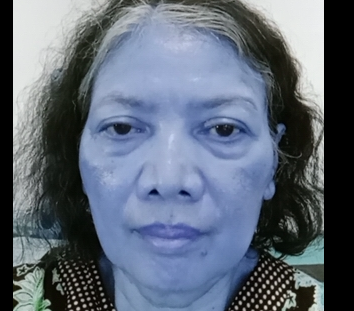

In [6]:
from PIL import Image
Image.fromarray(img_cropped_df)